# Sentiment Analysis on Sephora Beauty Product Reviews (LSTM)

**Goal:** Build a deep learning model (LSTM) that reads a beauty product review and predicts whether the sentiment is **Positive** or **Negative**.

**Dataset:** [Sephora Products and Skincare Reviews](https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews) (Kaggle) — 8,000+ products and ~1 million reviews from Sephora's skincare category.

**Why this project uses Deep Learning:** Reviews are *sequential* text — word order and context matter ("not good" vs "good"). An LSTM reads the review word by word and carries forward a memory of what it has read, which lets it understand context in a way classical ML (e.g. bag-of-words + Logistic Regression) typically can't.


## Step 0 — Get the dataset

You have three options (pick whichever is easiest for you):

1. **Kaggle Notebook (easiest, no download needed):** Create a new notebook on kaggle.com, click "Add Input" → search "Sephora Products and Skincare Reviews" → add it. The files will appear under `/kaggle/input/sephora-products-and-skincare-reviews/`.
2. **Google Colab + Kaggle API:** Upload your `kaggle.json` API token (from your Kaggle account settings), then run:
   ```
   !pip install kaggle -q
   !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/
   !chmod 600 ~/.kaggle/kaggle.json
   !kaggle datasets download -d nadyinky/sephora-products-and-skincare-reviews
   !unzip -q sephora-products-and-skincare-reviews.zip -d sephora_data
   ```
3. **Manual download:** Download the ZIP from the Kaggle page above, unzip it, and upload the review CSV file(s) to your Colab/Jupyter environment.

The dataset has a `product_info.csv` and one or more review files (named something like `reviews_0-250.csv`, `reviews_250-500.csv`, etc. — Kaggle sometimes splits large review files). The code below automatically finds and combines **all** files that start with `reviews` in your data folder, so it works regardless of how many parts there are.

**Set your data folder path below before running.**


In [1]:
DATA_DIR = "/kaggle/input/datasets/nadyinky/sephora-products-and-skincare-reviews"

In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
import os
print(os.listdir("/kaggle/input/datasets"))

['nadyinky']


In [4]:
import os
print(os.listdir("/kaggle/input/datasets/nadyinky"))

['sephora-products-and-skincare-reviews']


In [5]:
import pandas as pd
import numpy as np
import re
import glob
import os

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)


## Step 1 — Load the review data

We only need the **review text** and the **star rating** for sentiment analysis (we don't need `product_info.csv` for this part).


In [6]:
# Find and combine all review CSV files in the data folder
review_files = sorted(glob.glob(os.path.join(DATA_DIR, "reviews*.csv")))
print("Found review files:", review_files)

df_list = [pd.read_csv(f) for f in review_files]
df = pd.concat(df_list, ignore_index=True)
print("Total reviews loaded:", df.shape)
df.head()


Found review files: ['/kaggle/input/datasets/nadyinky/sephora-products-and-skincare-reviews/reviews_0-250.csv', '/kaggle/input/datasets/nadyinky/sephora-products-and-skincare-reviews/reviews_1250-end.csv', '/kaggle/input/datasets/nadyinky/sephora-products-and-skincare-reviews/reviews_250-500.csv', '/kaggle/input/datasets/nadyinky/sephora-products-and-skincare-reviews/reviews_500-750.csv', '/kaggle/input/datasets/nadyinky/sephora-products-and-skincare-reviews/reviews_750-1250.csv']


/tmp/ipykernel_58/1399378392.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in review_files]
/tmp/ipykernel_58/1399378392.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in review_files]


Total reviews loaded: (1094411, 19)


/tmp/ipykernel_58/1399378392.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in review_files]


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


In [7]:
# The dataset uses 'review_text' and 'rating' columns.
# If your column names differ slightly, rename them here, e.g.:
# df = df.rename(columns={"Review Text": "review_text", "Rating": "rating"})

df = df.dropna(subset=["review_text", "rating"]).reset_index(drop=True)
print(df.shape)
df[["review_text", "rating"]].head()


(1092967, 19)


,review_text,rating
0,I use this with the Nudestix “Citrus Clean Bal...,5
1,I bought this lip mask after reading the revie...,1
2,My review title says it all! I get so excited ...,5
3,I’ve always loved this formula for a long time...,5
4,"If you have dry cracked lips, this is a must h...",5


## Step 2 — Turn star ratings into sentiment labels

Reviews come with 1–5 star ratings, not "positive/negative" labels, so we map them ourselves:
- **4–5 stars → Positive (1)**
- **1–2 stars → Negative (0)**
- **3 stars → Neutral → dropped** (keeps the task a clean binary classification, which is easier to train and explain)


sentiment
1    897154
0    114061
Name: count, dtype: int64


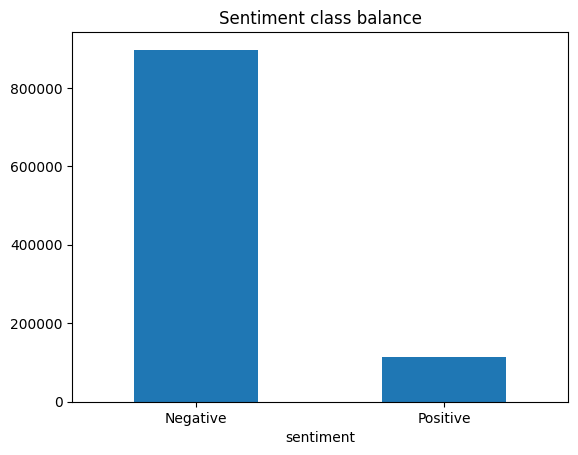

In [8]:
def rating_to_sentiment(r):
    if r >= 4:
        return 1   # positive
    elif r <= 2:
        return 0   # negative
    else:
        return None  # neutral, drop

df["sentiment"] = df["rating"].apply(rating_to_sentiment)
df = df.dropna(subset=["sentiment"]).reset_index(drop=True)
df["sentiment"] = df["sentiment"].astype(int)

print(df["sentiment"].value_counts())
df["sentiment"].value_counts().plot(kind="bar", title="Sentiment class balance")
plt.xticks([0,1], ["Negative","Positive"], rotation=0)
plt.show()


## Step 3 — Sample the data down (important for speed!)

The full dataset has ~1 million reviews. Using all of them will make loading and training painfully slow for an assignment with a deadline. We take a **stratified sample** (keeps the same positive/negative balance) of a manageable size instead.

Feel free to raise `SAMPLE_SIZE` later if you have time to spare — but 30,000 rows is already plenty for a solid LSTM demo.


In [9]:
SAMPLE_SIZE = 30000  # lower this (e.g. 10000) if training is still too slow on your machine

if len(df) > SAMPLE_SIZE:
    df, _ = train_test_split(
        df, train_size=SAMPLE_SIZE, stratify=df["sentiment"], random_state=42
    )
df = df.reset_index(drop=True)
print("Working with:", df.shape)


Working with: (30000, 20)


## Step 4 — Clean the review text

We lowercase everything, strip out HTML/punctuation/numbers, and collapse extra whitespace. This keeps only the words themselves, which is what the model will learn from.


In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)         # remove HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)       # keep letters only
    text = re.sub(r"\s+", " ", text).strip()    # collapse whitespace
    return text

df["clean_text"] = df["review_text"].apply(clean_text)
df[["review_text", "clean_text"]].head()


,review_text,clean_text
0,LOVE this product and this brand. Makes my ski...,love this product and this brand makes my skin...
1,"From all these raving reviews, I wanted to lov...",from all these raving reviews i wanted to love...
2,"I have dry, sensitive skin. Not the “my skin i...",i have dry sensitive skin not the my skin is j...
3,My husband has facial psoriasis and he uses th...,my husband has facial psoriasis and he uses th...
4,This stuff SMELLS AMAZING! Love how light the ...,this stuff smells amazing love how light the c...


## Step 5 — Train / test split


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["sentiment"],
    test_size=0.2, random_state=42, stratify=df["sentiment"]
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (24000,) Test: (6000,)


## Step 6 — Tokenize and pad the text

Neural networks need numbers, not words. The `Tokenizer` converts each word into an integer ID (based on the most common `VOCAB_SIZE` words), and `pad_sequences` makes every review the same length (`MAX_LEN`) by cutting long ones and padding short ones with zeros — LSTMs need fixed-size input batches.


In [12]:
VOCAB_SIZE = 10000   # keep the 10,000 most common words
MAX_LEN = 60          # most reviews will fit comfortably in 60 words

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Train shape:", X_train_pad.shape, "Test shape:", X_test_pad.shape)


Train shape: (24000, 60) Test shape: (6000, 60)


## Step 7 — Build the LSTM model

- **Embedding layer:** turns each word ID into a learned vector that captures meaning (similar words end up with similar vectors).
- **LSTM layer:** reads the sequence of word vectors and builds up a "memory" of the review as it goes.
- **Dense layers:** take that memory and make the final Positive/Negative decision.


In [13]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),   # outputs a probability between 0 (negative) and 1 (positive)
])

model.build(input_shape=(None, MAX_LEN))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


2026-09-30 12:26:46.822875: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

## Step 8 — Train the model

`EarlyStopping` watches the validation loss and stops training automatically if the model stops improving, so you don't waste time overtraining (or need to guess the right number of epochs).


In [14]:
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.8849 - loss: 0.3749 - val_accuracy: 0.8917 - val_loss: 0.3429
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8867 - loss: 0.3589 - val_accuracy: 0.8917 - val_loss: 0.3440
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8850 - loss: 0.3101 - val_accuracy: 0.8917 - val_loss: 0.3055
Epoch 4/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9060 - loss: 0.2397 - val_accuracy: 0.9146 - val_loss: 0.2044
Epoch 5/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9388 - loss: 0.1604 - val_accuracy: 0.9279 - val_loss: 0.1784
Epoch 6/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9567 - loss: 0.1182 - val_accuracy: 0.9342 - val_loss: 0.1756
Epoch 7/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9655 - loss: 0.0971 - val_accuracy: 0.9417 - val_loss: 0.1851
Epoch 8/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9744 - loss: 0.0790 - 

## Step 9 — Evaluate the model


Test accuracy: 0.937


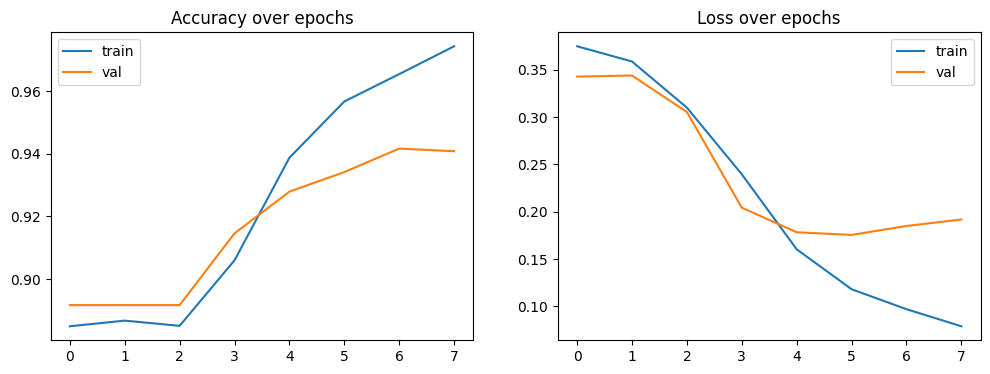

In [15]:
loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy over epochs")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss over epochs")
axes[1].legend()
plt.show()


              precision    recall  f1-score   support

    Negative       0.74      0.68      0.71       677
    Positive       0.96      0.97      0.96      5323

    accuracy                           0.94      6000
   macro avg       0.85      0.82      0.84      6000
weighted avg       0.93      0.94      0.94      6000



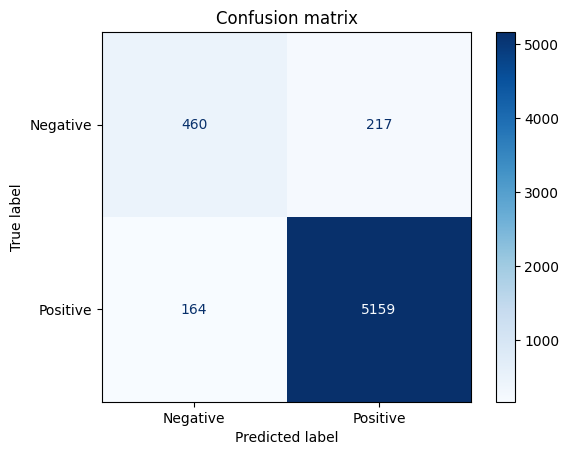

In [16]:
y_pred_prob = model.predict(X_test_pad, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Negative","Positive"]).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()


## Step 10 — Try it on your own reviews

A quick sanity check with reviews the model has never seen — good for demonstrating the model in your report/presentation.


In [17]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    prob = model.predict(padded, verbose=0)[0][0]
    label = "Positive" if prob > 0.5 else "Negative"
    return label, round(float(prob), 3)

sample_reviews = [
    "This serum completely transformed my skin, I'm obsessed!",
    "Broke me out so badly, complete waste of money.",
    "It's okay, nothing special but not bad either.",
    "Best moisturizer I've ever tried, will repurchase forever.",
]

for r in sample_reviews:
    print(f"{r!r} -> {predict_sentiment(r)}")


"This serum completely transformed my skin, I'm obsessed!" -> ('Positive', 0.997)
'Broke me out so badly, complete waste of money.' -> ('Negative', 0.061)
"It's okay, nothing special but not bad either." -> ('Negative', 0.067)
"Best moisturizer I've ever tried, will repurchase forever." -> ('Positive', 0.997)


## Wrap-up (for your report)

- **Problem:** Predict whether a Sephora beauty product review is Positive or Negative.
- **Why Deep Learning:** Text is sequential — an LSTM captures word order and context (e.g. negation, "but" flipping sentiment) far better than classical bag-of-words models.
- **Data prep:** Sampled ~30K reviews from ~1M, converted star ratings into binary sentiment labels, cleaned text, tokenized and padded sequences.
- **Model:** Embedding → LSTM → Dense layers, trained with early stopping to avoid overfitting.
- **Result:** Report your test accuracy, and mention the confusion matrix / classification report above — call out any class imbalance you saw in Step 2.
- **Real-world relevance:** This is exactly the kind of pipeline a company would use to automatically monitor customer sentiment on product reviews at scale.
